In [2]:
import numpy as np
import pandas as pd
import random
from datetime import datetime, timedelta
import pm4py
from pm4py.objects.conversion.log import converter as log_converter
from pm4py.objects.log.exporter.xes import exporter as xes_exporter


import seaborn as sns
import matplotlib.pyplot as plt


## Event/transition sequence generator

In [47]:
# OLD without stochastic rounding
def OLD_generate_transition_sequence_relaxed_structural(E: int, density: float, sigma_we: float, seed: int = None) -> tuple[int, list[str]]:
    """
    Generates a sequence where density > 1 (sparse) or density < 1 (clustered).
    Uses a constructive approach (Skeleton -> Injection -> Expansion) for O(N) performance.
    Correctly handles density=0.0 by utilizing the seed event as an anchor.
    """
    rng = random.Random(seed)

    # 1. Parameter Calculation
    event_slots_to_fill = E - 1
    num_crossings = round(event_slots_to_fill * density)
    
    num_we = round(num_crossings * sigma_we)
    sigma_wd = 1- sigma_we
    num_wd = round(num_crossings * sigma_wd)
    
    # Intra-day: Events occurring on the same day as a predecessor
    num_intra = max(0, event_slots_to_fill - num_crossings)
    
    # Sparse: Events occurring after a transition
    events_to_place = event_slots_to_fill - num_intra

    # 2. Construct Calendar Skeleton (Deterministic Simulation)
    possible_start_days = [1, 2, 3, 4, 5]
    rng.shuffle(possible_start_days)
    
    skeleton = []
    final_start_day = None
    
    # If no crossings are needed, any start day is valid and skeleton is empty
    if num_crossings == 0:
        final_start_day = possible_start_days[0]
        skeleton = []
    else:
        for sd in possible_start_days:
            temp_skeleton = []
            current_day = sd
            rem_wd, rem_we = num_wd, num_we
            valid_chain = True
            
            while rem_wd > 0 or rem_we > 0:
                if current_day == 5: # Friday
                    if rem_we > 0:
                        temp_skeleton.append('WE')
                        rem_we -= 1
                        current_day = 1 
                    else:
                        valid_chain = False
                        break
                else: # Mon-Thu
                    if rem_wd > 0:
                        temp_skeleton.append('WD')
                        rem_wd -= 1
                        current_day += 1
                    else:
                        valid_chain = False
                        break
            
            if valid_chain:
                skeleton = temp_skeleton
                final_start_day = sd
                break
                
        if final_start_day is None:
             raise ValueError(f"No valid calendar chain found for WD={num_wd}, WE={num_we}.")

    # 3. Identify Event Buckets (Sparse Injection)
    # Buckets are locations where an EVENT exists. Intra events can cluster into these buckets.
    # Bucket -1 always exists (The initial Seed Event).
    
    valid_buckets = [-1] # -1 represents the 'Seed' event before any transition
    
    # If we have a skeleton, we must place 'events_to_place' sparse events within it.
    if len(skeleton) > 0:
        required_sparse = events_to_place
        
        # Guard: Cannot place more sparse events than there are transitions
        if required_sparse > len(skeleton):
             raise ValueError("density too high: Not enough transitions to support sparse events.")
             
        # We identify indices in the skeleton to attach an EVENT to.
        # We MUST attach one to the very end (len-1) to ensure termination.
        sparse_indices = set()
        
        if required_sparse > 0:
            sparse_indices.add(len(skeleton) - 1)
            
            if required_sparse > 1:
                # Available slots are strictly before the last item
                available_slots = range(len(skeleton) - 1)
                chosen_slots = rng.sample(available_slots, required_sparse - 1)
                sparse_indices.update(chosen_slots)
        
        # Add these chosen sparse locations to our list of valid buckets for intra events
        valid_buckets.extend(sorted(list(sparse_indices)))

    # 4. Intra-Day Expansion (Clustering)
    # Distribute num_intra events randomly into the identified valid buckets.
    
    bucket_counts = {b: 0 for b in valid_buckets}
    
    for _ in range(num_intra):
        target = rng.choice(valid_buckets)
        bucket_counts[target] += 1

    # 5. Sequence Reconstruction
    final_sequence = ['EVENT']
    
    # Expand the Seed Event (Bucket -1)
    # This handles the density=0 case where all events cluster here.
    seed_intra_count = bucket_counts.get(-1, 0)
    for _ in range(seed_intra_count):
        final_sequence.extend(['INTRA', 'EVENT'])
    
    # Expand the Skeleton
    for i, token in enumerate(skeleton):
        final_sequence.append(token)
        
        # If this transition index was chosen for a Sparse Event
        if i in bucket_counts and i != -1:
            final_sequence.append('EVENT')
            
            # Expand any Intra events attached to this Sparse Event
            intra_count = bucket_counts[i]
            for _ in range(intra_count):
                final_sequence.extend(['INTRA', 'EVENT'])

    return final_start_day, final_sequence

In [48]:
def generate_transition_sequence_relaxed_structural(E: int, density: float, sigma_we: float, seed: int = None) -> tuple[int, list[str]]:
    """
    Generates a sequence where density > 1 (sparse) or density < 1 (clustered).
    Uses a constructive approach (Skeleton -> Injection -> Expansion) for O(N) performance.
    Utilizes stochastic rounding for transition quotas to prevent start-day phase locking.
    """
    rng = random.Random(seed)

    event_slots_to_fill = E - 1
    num_crossings = round(event_slots_to_fill * density)
    
    exact_we = num_crossings * sigma_we
    base_we = int(exact_we)
    prob_we = exact_we - base_we
    
    num_we = base_we + 1 if rng.random() < prob_we else base_we
    num_wd = num_crossings - num_we
    
    num_intra = max(0, event_slots_to_fill - num_crossings)
    events_to_place = event_slots_to_fill - num_intra

    possible_start_days = [1, 2, 3, 4, 5]
    rng.shuffle(possible_start_days)
    
    skeleton = []
    final_start_day = None
    
    if num_crossings == 0:
        final_start_day = possible_start_days[0]
        skeleton = []
    else:
        for sd in possible_start_days:
            temp_skeleton = []
            current_day = sd
            rem_wd, rem_we = num_wd, num_we
            valid_chain = True
            
            while rem_wd > 0 or rem_we > 0:
                if current_day == 5: 
                    if rem_we > 0:
                        temp_skeleton.append('WE')
                        rem_we -= 1
                        current_day = 1 
                    else:
                        valid_chain = False
                        break
                else: 
                    if rem_wd > 0:
                        temp_skeleton.append('WD')
                        rem_wd -= 1
                        current_day += 1
                    else:
                        valid_chain = False
                        break
            
            if valid_chain:
                skeleton = temp_skeleton
                final_start_day = sd
                break
                
        if final_start_day is None:
             raise ValueError(f"No valid calendar chain found for WD={num_wd}, WE={num_we}.")

    valid_buckets = [-1] 
    
    if len(skeleton) > 0:
        required_sparse = events_to_place
        
        if required_sparse > len(skeleton):
             raise ValueError("density too high: Not enough transitions to support sparse events.")
             
        sparse_indices = set()
        
        if required_sparse > 0:
            sparse_indices.add(len(skeleton) - 1)
            
            if required_sparse > 1:
                available_slots = range(len(skeleton) - 1)
                chosen_slots = rng.sample(available_slots, required_sparse - 1)
                sparse_indices.update(chosen_slots)
        
        valid_buckets.extend(sorted(list(sparse_indices)))

    bucket_counts = {b: 0 for b in valid_buckets}
    
    for _ in range(num_intra):
        target = rng.choice(valid_buckets)
        bucket_counts[target] += 1

    final_sequence = ['EVENT']
    
    seed_intra_count = bucket_counts.get(-1, 0)
    for _ in range(seed_intra_count):
        final_sequence.extend(['INTRA', 'EVENT'])
    
    for i, token in enumerate(skeleton):
        final_sequence.append(token)
        
        if i in bucket_counts and i != -1:
            final_sequence.append('EVENT')
            
            intra_count = bucket_counts[i]
            for _ in range(intra_count):
                final_sequence.extend(['INTRA', 'EVENT'])

    return final_start_day, final_sequence

In [49]:
# try grid of parameter combinations
E = 8
for density in [0.0, 0.5, 1.0, 3.0]:
    for sigma_we in [0.0, 0.1, 0.2]:
        
        try:
            if density == 0.0 and sigma_we > 0:
                raise ValueError
            print(f"({density}, {sigma_we}): {generate_transition_sequence_relaxed_structural(E=E, density=density, sigma_we=sigma_we)}")
        except ValueError as e:
            print(f"({density}, {sigma_we}): Invalid")

(0.0, 0.0): (4, ['EVENT', 'INTRA', 'EVENT', 'INTRA', 'EVENT', 'INTRA', 'EVENT', 'INTRA', 'EVENT', 'INTRA', 'EVENT', 'INTRA', 'EVENT', 'INTRA', 'EVENT'])
(0.0, 0.1): Invalid
(0.0, 0.2): Invalid
(0.5, 0.0): (1, ['EVENT', 'INTRA', 'EVENT', 'WD', 'EVENT', 'WD', 'EVENT', 'WD', 'EVENT', 'INTRA', 'EVENT', 'INTRA', 'EVENT', 'WD', 'EVENT'])
(0.5, 0.1): (1, ['EVENT', 'WD', 'EVENT', 'INTRA', 'EVENT', 'INTRA', 'EVENT', 'INTRA', 'EVENT', 'WD', 'EVENT', 'WD', 'EVENT', 'WD', 'EVENT'])
(0.5, 0.2): (4, ['EVENT', 'INTRA', 'EVENT', 'INTRA', 'EVENT', 'WD', 'EVENT', 'WE', 'EVENT', 'WD', 'EVENT', 'INTRA', 'EVENT', 'WD', 'EVENT'])
(1.0, 0.0): Invalid
(1.0, 0.1): (1, ['EVENT', 'WD', 'EVENT', 'WD', 'EVENT', 'WD', 'EVENT', 'WD', 'EVENT', 'WE', 'EVENT', 'WD', 'EVENT', 'WD', 'EVENT'])
(1.0, 0.2): (4, ['EVENT', 'WD', 'EVENT', 'WE', 'EVENT', 'WD', 'EVENT', 'WD', 'EVENT', 'WD', 'EVENT', 'WD', 'EVENT', 'WE', 'EVENT'])
(3.0, 0.0): Invalid
(3.0, 0.1): Invalid
(3.0, 0.2): (3, ['EVENT', 'WD', 'WD', 'WE', 'WD', 'WD', 'WD'

In [50]:
def generate_multiple_sequences(n: int, E: int, density: float, sigma_we: float, seed: int = None) -> list[tuple[int, list[str]]]:
    sequences = []
    for i in range(n):
        sequence = generate_transition_sequence_relaxed_structural(E=E, density=density, sigma_we=sigma_we)
        sequences.append(sequence)

    return sequences

### Generate uniform archetype sequence

In [51]:
# generate series of sequences
n = 3000
E = 4
density = 9
sigma_we = 0.2

sequences = generate_multiple_sequences(n, E, density, sigma_we=sigma_we)
sequences

[(2,
  ['EVENT',
   'WD',
   'WD',
   'WD',
   'EVENT',
   'WE',
   'WD',
   'WD',
   'WD',
   'WD',
   'EVENT',
   'WE',
   'WD',
   'WD',
   'WD',
   'WD',
   'WE',
   'WD',
   'WD',
   'WD',
   'WD',
   'WE',
   'WD',
   'WD',
   'WD',
   'WD',
   'WE',
   'WD',
   'WD',
   'WD',
   'EVENT']),
 (1,
  ['EVENT',
   'WD',
   'WD',
   'WD',
   'WD',
   'EVENT',
   'WE',
   'WD',
   'WD',
   'WD',
   'WD',
   'WE',
   'WD',
   'WD',
   'WD',
   'WD',
   'WE',
   'WD',
   'WD',
   'WD',
   'WD',
   'EVENT',
   'WE',
   'WD',
   'WD',
   'WD',
   'WD',
   'WE',
   'WD',
   'WD',
   'EVENT']),
 (1,
  ['EVENT',
   'WD',
   'WD',
   'WD',
   'WD',
   'WE',
   'WD',
   'WD',
   'WD',
   'WD',
   'WE',
   'WD',
   'WD',
   'EVENT',
   'WD',
   'WD',
   'WE',
   'WD',
   'EVENT',
   'WD',
   'WD',
   'WD',
   'WE',
   'WD',
   'WD',
   'WD',
   'WD',
   'WE',
   'WD',
   'WD',
   'EVENT']),
 (1,
  ['EVENT',
   'WD',
   'WD',
   'WD',
   'WD',
   'WE',
   'WD',
   'WD',
   'WD',
   'WD',
   'WE',

### Generte mixed sequence

In [270]:
#parameters = [(1500, 10, 0.0, 0.0), (1500, 10, 9.0, 0.2)] # density dichotomy (density variation)
#parameters = [(1500, 4, 1.0, 0.2), (1500, 20, 1.0, 0.2)] # length dichotomy (length variation)
#parameters = [(1500, 4, 0.0, 0.0), (1500, 20, 9.0, 0.2)] # diagonal 1
#parameters = [(1500, 4, 9.0, 0.2), (1500, 20, 0.0, 0.0)] # diagonal 2
parameters = [(int(0.04*3000),  4, 0.0, 0.0), 
              (int(0.01*3000),  4, 0.5, 0.2),
              (int(0.18*3000),  4, 1.0, 0.2),
              (int(0.41*3000),  4, 3.0, 0.2),
              (int(0.08*3000),  4, 9.0, 0.2),
              (int(0.01*3000), 10, 0.0, 0.0), 
              (int(0.03*3000), 10, 0.5, 0.2),
              (int(0.14*3000), 10, 1.0, 0.2),
              (int(0.08*3000), 10, 3.0, 0.2),
              (int(0.00*3000), 10, 9.0, 0.2),
              (int(0.00*3000), 20, 0.0, 0.0), 
              (int(0.01*3000), 20, 0.5, 0.2),
              (int(0.01*3000), 20, 1.0, 0.2),
              (int(0.00*3000), 20, 3.0, 0.2),
              (int(0.00*3000), 20, 9.0, 0.2)] # BPI 2012 A


sequences = []

for params in parameters:
    n, E, density, sigma_we = params
    seq = generate_multiple_sequences(n, E, density, sigma_we=sigma_we)
    sequences.extend(seq)  
#sequences

In [272]:
start_days = []
seqs = []
for start_day, seq in sequences:
    start_days.append(start_day)
    seqs.append(seq)

#pd.Series(start_days).describe()
counts_of_we = [sublist.count("WE") for sublist in seqs]
counts_of_wd = [sublist.count("WD") for sublist in seqs]

pd.Series(counts_of_wd).describe()


count    3000.000000
mean        8.187000
std         6.361409
min         0.000000
25%         3.000000
50%         7.000000
75%         8.000000
max        22.000000
dtype: float64

## Log instantiation

In [54]:
def instantiate_case_timestamps(start_day: int, sequence: list[str], case_id: str, base_date: datetime, seed: int = None) -> pd.DataFrame:
    """
    Translates a sequence of temporal tokens into a DataFrame of timestamped events.
    Events are distributed evenly across an active working day window.
    """
    rng = random.Random(seed)
    
    daily_event_counts = []
    calendar_advancements = []
    current_day_events = 0
    
    for token in sequence:
        if token == 'EVENT':
            current_day_events += 1
        elif token == 'WD':
            daily_event_counts.append(current_day_events)
            calendar_advancements.append(timedelta(days=1))
            current_day_events = 0
        elif token == 'WE':
            daily_event_counts.append(current_day_events)
            calendar_advancements.append(timedelta(days=3))
            current_day_events = 0
            
    daily_event_counts.append(current_day_events)
    
    current_date = base_date + timedelta(days=(start_day - 1))
    events = []
    event_counter = 0
    
    working_minutes = 540 
    
    for i, count in enumerate(daily_event_counts):
        if count > 0:
            bucket_size = working_minutes / count
            
            for j in range(count):
                noise = rng.randint(0, int(bucket_size) - 1) if int(bucket_size) > 0 else 0
                minutes_offset = int(j * bucket_size) + noise
                
                event_time = current_date + timedelta(hours=8, minutes=minutes_offset)
                
                events.append({
                    "case:concept:name": case_id,
                    "concept:name": f"Activity_{event_counter}",
                    "time:timestamp": event_time
                })
                event_counter += 1
                
        if i < len(calendar_advancements):
            current_date += calendar_advancements[i]
            
    return pd.DataFrame(events)

In [55]:
def instantiate_log(sequences: list[tuple[int, list]], num_weeks: int = 12, base_monday: datetime = datetime(2026, 1, 5)) -> pd.DataFrame:
    cases = []
    for i, sequence in enumerate(sequences):
        week_offset = random.randint(0, num_weeks - 1)
        
        case_base_date = base_monday + timedelta(weeks=week_offset)
        
        case = instantiate_case_timestamps(
            start_day=sequence[0],
            sequence=sequence[1],
            case_id=f"Case_{i:04}",
            base_date=case_base_date
        )
        
        cases.append(case)

    log = pd.concat(cases, ignore_index=True)
    log = log.sort_values(by=['case:concept:name', 'time:timestamp']).reset_index(drop=True)
    
    return log

### Instantiate single log

In [273]:
log = instantiate_log(sequences)

In [57]:
def save_log(path: str, log: pd.DataFrame):
    user_input = input(f"Save log to {path}? (y/n): ").strip().lower()
    if user_input in ["y"]:
        xes_log = log_converter.apply(log, variant=log_converter.Variants.TO_EVENT_LOG)
        xes_exporter.apply(xes_log, path)
    else:
        print("Saving aborted")

In [274]:
#path = f"syn/syn_E{E:02d}_sp{int(density*10):02d}_we{int(sigma_we*10):02d}.xes"
path = f"syn/syn_mix_BPI_2012_A.xes"
save_log(path, log)

exporting log, completed traces :: 100%|██████████| 3000/3000 [00:00<00:00, 18601.70it/s]


In [168]:
path

'syn/syn_E10_sp10_we02.xes'

### Instantiate group of logs

In [ ]:
E = 20
#sigma_we = 0.2
n = 3000

#combinations = [(0.0, 0.0), (0.5, 0.0), (0.5, 0.2), (1.0, 0.0), (1.0, 0.2), (3.0, 0.2), (9.0, 0.2)]
#combinations = [(0.0, 0.0), (0.5, 0.0), (0.5, 0.2), (1.0, 0.2), (3.0, 0.2), (9.0, 0.2)]
combinations = [(0.0, 0.0), (0.5, 0.2), (1.0, 0.2), (3.0, 0.2), (9.0, 0.2)]


for density, sigma_we in combinations:
    sequences = generate_multiple_sequences(n, E, density, sigma_we)
    log = instantiate_log(sequences)
    
    path = f"syn/syn_E{E:02d}_sp{int(density*10):02d}_we{int(sigma_we*10):02d}.xes"
    save_log(path, log)

exporting log, completed traces :: 100%|██████████| 3000/3000 [00:00<00:00, 6526.29it/s]


## Real-life log analysis

### Extract sequences

In [3]:
def filter_weekend_cases(log_df: pd.DataFrame, case_col: str = 'case:concept:name', time_col: str = 'time:timestamp') -> pd.DataFrame:
    """
    Removes all cases from the event log that contain one or more weekend events.
    Prints the volume and relative share of the removed cases and events.
    """
    if not pd.api.types.is_datetime64_any_dtype(log_df[time_col]):
        log_df[time_col] = pd.to_datetime(log_df[time_col])

    is_weekend = log_df[time_col].dt.dayofweek >= 5
    
    cases_with_weekend = log_df[is_weekend][case_col].unique()
    
    total_cases = log_df[case_col].nunique()
    total_events = len(log_df)
    
    num_removed_cases = len(cases_with_weekend)
    share_removed_cases = num_removed_cases / total_cases if total_cases > 0 else 0.0
    
    filtered_df = log_df[~log_df[case_col].isin(cases_with_weekend)].copy()
    
    num_removed_events = total_events - len(filtered_df)
    share_removed_events = num_removed_events / total_events if total_events > 0 else 0.0
    
    print(f"Removed {num_removed_cases} cases ({share_removed_cases:.2%} of {total_cases} total cases).")
    print(f"Removed {num_removed_events} events ({share_removed_events:.2%} of {total_events} total events).")
    
    return filtered_df

In [4]:
def project_weekend_events(log_df: pd.DataFrame, time_col: str = 'time:timestamp') -> pd.DataFrame:
    """
    Projects weekend timestamps onto adjacent business days to maintain a 5-day calendar model.
    Saturday and Sunday events are shifted to the following Monday at 08:00:00.
    Prints the volume and relative share of the projected events.
    """
    processed_df = log_df.copy()
    
    if not pd.api.types.is_datetime64_any_dtype(processed_df[time_col]):
        processed_df[time_col] = pd.to_datetime(processed_df[time_col])
        
    weekdays = processed_df[time_col].dt.dayofweek
    
    is_saturday = weekdays == 5
    is_sunday = weekdays == 6
    
    total_events = len(processed_df)
    num_projected = is_saturday.sum() + is_sunday.sum()
    share_projected = num_projected / total_events if total_events > 0 else 0.0
    
    print(f"Projected {num_projected} weekend events ({share_projected:.2%} of {total_events} total events).")
    
    if num_projected > 0:
        processed_df.loc[is_saturday, time_col] = (
            processed_df.loc[is_saturday, time_col].dt.normalize() + 
            pd.Timedelta(days=2, hours=8)
        )
        
        processed_df.loc[is_sunday, time_col] = (
            processed_df.loc[is_sunday, time_col].dt.normalize() + 
            pd.Timedelta(days=1, hours=8)
        )
        
        processed_df = processed_df.sort_values(by=[time_col])
        
    return processed_df

In [74]:
import pm4py 
df_raw = pm4py.read_xes("../../data/request_for_payment.xes")
df_filtered = filter_weekend_cases(df_raw)
#df_projected = project_weekend_events(df_raw)

df = df_filtered

parsing log, completed traces :: 100%|██████████| 6886/6886 [00:01<00:00, 6732.91it/s]


Removed 649 cases (9.42% of 6886 total cases).
Removed 3773 events (10.25% of 36796 total events).


In [75]:
def extract_sequences_from_log(log_df: pd.DataFrame, case_col: str = 'case:concept:name', time_col: str = 'time:timestamp') -> pd.DataFrame:
    """
    Translates raw event log timestamps into abstract calendar token sequences.
    Calculates absolute frequencies, relative shares, and cumulative distributions.
    """
    log_df = log_df.sort_values(by=[case_col, time_col])
    
    extracted_data = []
    
    for case_id, group in log_df.groupby(case_col):
        timestamps = group[time_col].tolist()
        
        if len(timestamps) < 2:
            continue
            
        start_date = timestamps[0]
        start_day = start_date.isoweekday()
        
        sequence = ['EVENT']
        
        for i in range(len(timestamps) - 1):
            d1 = timestamps[i].date()
            d2 = timestamps[i+1].date()
            
            if d1 == d2:
                sequence.extend(['INTRA', 'EVENT'])
            else:
                curr_date = d1
                while curr_date < d2:
                    if curr_date.weekday() == 4: 
                        sequence.append('WE')
                        curr_date += timedelta(days=3)
                    elif curr_date.weekday() < 4:
                        sequence.append('WD')
                        curr_date += timedelta(days=1)
                    else:
                        curr_date += timedelta(days=1)
                
                sequence.append('EVENT')
                
        extracted_data.append({
            'start_day': start_day,
            'sequence_tuple': tuple(sequence) 
        })
        
    seq_df = pd.DataFrame(extracted_data)
    
    summary_df = seq_df.groupby(['start_day', 'sequence_tuple']).size().reset_index(name='absolute_frequency')
    summary_df = summary_df.sort_values(by='absolute_frequency', ascending=False).reset_index(drop=True)
    
    total_cases = summary_df['absolute_frequency'].sum()
    summary_df['relative_share'] = summary_df['absolute_frequency'] / total_cases
    summary_df['cumulative_relative_share'] = summary_df['relative_share'].cumsum()
    
    return summary_df

In [76]:
sequence_df = extract_sequences_from_log(log_df=df)

print(f"Number of sequences identified: {len(sequence_df)}")
sequence_df.head(10)

Number of sequences identified: 2061


,start_day,sequence_tuple,absolute_frequency,relative_share,cumulative_relative_share
0,1,"(EVENT, INTRA, EVENT, INTRA, EVENT, WD, EVENT,...",128,0.020752,0.020752
1,2,"(EVENT, INTRA, EVENT, WD, EVENT, WD, EVENT, WD...",117,0.018969,0.039721
2,3,"(EVENT, INTRA, EVENT, INTRA, EVENT, WD, EVENT,...",88,0.014267,0.053988
3,1,"(EVENT, INTRA, EVENT, WD, EVENT, INTRA, EVENT,...",86,0.013943,0.067931
4,5,"(EVENT, INTRA, EVENT, WE, EVENT, WD, EVENT, WD...",83,0.013457,0.081388
5,3,"(EVENT, INTRA, EVENT, WD, EVENT, INTRA, EVENT,...",58,0.009403,0.090791
6,4,"(EVENT, INTRA, EVENT, WD, EVENT, WE, WD, EVENT...",56,0.009079,0.099870
7,1,"(EVENT, INTRA, EVENT, WD, EVENT, WD, WD, EVENT)",55,0.008917,0.108787
8,4,"(EVENT, INTRA, EVENT, WD, WE, EVENT, WD, EVENT...",55,0.008917,0.117704
9,1,"(EVENT, INTRA, EVENT, WD, WD, EVENT, WD, EVENT...",54,0.008755,0.126459


### Aggregate to parameters

In [77]:
def aggregate_to_parameters(sequences_df: pd.DataFrame, share_bucket_size: float = 0.0) -> pd.DataFrame:
    """
    Parses token sequences into high-level mathematical parameters.
    Aggregates the data to calculate frequencies, discrete shares, and cumulative distributions.
    """
    parameter_data = []
    
    for _, row in sequences_df.iterrows():
        seq = row['sequence_tuple']
        freq = row['absolute_frequency']
        
        num_events = seq.count('EVENT')
        num_wd = seq.count('WD')
        num_we = seq.count('WE')
        num_intra = seq.count('INTRA')
        
        total_transitions = num_wd + num_we + num_intra
        
        raw_share_wd = num_wd / total_transitions if total_transitions > 0 else 0.0
        raw_share_we = num_we / total_transitions if total_transitions > 0 else 0.0
        
        if share_bucket_size > 0:
            share_wd = round(round(raw_share_wd / share_bucket_size) * share_bucket_size, 4)
            share_we = round(round(raw_share_we / share_bucket_size) * share_bucket_size, 4)
        else:
            share_wd = round(raw_share_wd, 4)
            share_we = round(raw_share_we, 4)
            
        parameter_data.append({
            'num_events': num_events,
            'num_wd': num_wd,
            'share_wd': share_wd,
            'num_we': num_we,
            'share_we': share_we,
            'absolute_frequency': freq
        })
        
    param_df = pd.DataFrame(parameter_data)
    
    group_cols = ['num_events', 'num_wd', 'share_wd', 'num_we', 'share_we']
    summary_df = param_df.groupby(group_cols)['absolute_frequency'].sum().reset_index()
    
    summary_df = summary_df.sort_values(by='absolute_frequency', ascending=False).reset_index(drop=True)
    
    total_cases = summary_df['absolute_frequency'].sum()
    summary_df['relative_share'] = summary_df['absolute_frequency'] / total_cases
    summary_df['cumulative_relative_share'] = summary_df['relative_share'].cumsum()
    
    return summary_df

In [78]:
def aggregate_to_structural_vector(sequences_df: pd.DataFrame, density_bucket: float = 0.1, sigma_bucket: float = 0.05) -> pd.DataFrame:
    """
    Parses token sequences into the Structural Vector (E, density, Sigma_WE, Sigma_WD).
    Aggregates data based on these structural dimensions.
    
    Args:
        density_bucket: Rounding interval for the Crossing density (e.g., 0.1).
        sigma_bucket: Rounding interval for Weekend/Weekday Impact shares (e.g., 0.05).
    """
    parameter_data = []
    
    for _, row in sequences_df.iterrows():
        seq = row['sequence_tuple']
        freq = row['absolute_frequency']
        
        # 1. Raw Counts
        E = seq.count('EVENT')
        num_wd = seq.count('WD')
        num_we = seq.count('WE')
        
        # 2. Structural Calculations
        # Denominator for density is the number of 'slots' between events
        event_slots = E - 1
        total_crossings = num_wd + num_we
        
        # Calculate density (Delta_T)
        # Handle single-event cases (density 0)
        raw_density = total_crossings / event_slots if event_slots > 0 else 0.0
        
        # Calculate Impact Sigmas
        # Handle cases with no calendar crossings (sigma 0)
        raw_sigma_we = num_we / total_crossings if total_crossings > 0 else 0.0
        raw_sigma_wd = num_wd / total_crossings if total_crossings > 0 else 0.0
        
        # 3. Discretization (Bucketing)
        if density_bucket > 0:
            density = round(round(raw_density / density_bucket) * density_bucket, 2)
        else:
            density = round(raw_density, 4)
            
        if sigma_bucket > 0:
            sigma_we = round(round(raw_sigma_we / sigma_bucket) * sigma_bucket, 2)
            sigma_wd = round(round(raw_sigma_wd / sigma_bucket) * sigma_bucket, 2)
            
            # Correction to ensure Sigmas sum to 1.0 (if total_crossings > 0)
            if total_crossings > 0 and abs((sigma_we + sigma_wd) - 1.0) > 1e-6:
                # Adjust the larger share to force the sum to 1.0
                if sigma_wd >= sigma_we:
                    sigma_wd = round(1.0 - sigma_we, 2)
                else:
                    sigma_we = round(1.0 - sigma_wd, 2)
        else:
            sigma_we = round(raw_sigma_we, 4)
            sigma_wd = round(raw_sigma_wd, 4)
            
        parameter_data.append({
            'E': E,
            'density': density,
            'sigma_wd': sigma_wd,
            'sigma_we': sigma_we,
            'absolute_frequency': freq
        })
        
    param_df = pd.DataFrame(parameter_data)
    
    # 4. Aggregation & Metrics
    group_cols = ['E', 'density', 'sigma_wd', 'sigma_we']
    summary_df = param_df.groupby(group_cols)['absolute_frequency'].sum().reset_index()
    
    summary_df = summary_df.sort_values(by='absolute_frequency', ascending=False).reset_index(drop=True)
    
    total_cases = summary_df['absolute_frequency'].sum()
    summary_df['relative_share'] = summary_df['absolute_frequency'] / total_cases
    summary_df['cumulative_relative_share'] = summary_df['relative_share'].cumsum()
    
    return summary_df

In [79]:
parameter_df = aggregate_to_parameters(sequences_df=sequence_df, share_bucket_size=0.01)
print(f"Number of parameter sets identified: {len(parameter_df)}")
parameter_df.head(10)

Number of parameter sets identified: 646


,num_events,num_wd,share_wd,num_we,share_we,absolute_frequency,relative_share,cumulative_relative_share
0,5,4,0.67,1,0.17,319,0.051719,0.051719
1,5,3,0.60,1,0.20,254,0.041180,0.092899
2,5,3,0.60,0,0.00,241,0.039073,0.131971
3,5,3,0.50,1,0.17,231,0.037451,0.169423
4,5,4,0.57,1,0.14,175,0.028372,0.197795
5,5,2,0.40,1,0.20,166,0.026913,0.224708
6,6,4,0.57,1,0.14,132,0.021401,0.246109
7,4,3,0.60,1,0.20,131,0.021239,0.267348
8,5,5,0.71,1,0.14,124,0.020104,0.287451
9,5,6,0.75,1,0.12,101,0.016375,0.303826


In [80]:
structural_vector_df = aggregate_to_structural_vector(sequence_df, density_bucket=0.01, sigma_bucket=0.01)

print(f"Number of parameter sets identified: {len(structural_vector_df)}")
structural_vector_df.head(10)

Number of parameter sets identified: 400


,E,density,sigma_wd,sigma_we,absolute_frequency,relative_share,cumulative_relative_share
0,5,1.25,0.80,0.20,498,0.080739,0.080739
1,5,1.00,0.75,0.25,491,0.079604,0.160344
2,5,0.75,1.00,0.00,311,0.050422,0.210765
3,5,0.75,0.67,0.33,216,0.035019,0.245785
4,6,1.00,0.80,0.20,183,0.029669,0.275454
5,5,1.50,0.83,0.17,166,0.026913,0.302367
6,5,2.00,0.88,0.12,141,0.022860,0.325227
7,5,1.75,0.86,0.14,138,0.022374,0.347601
8,4,1.33,0.75,0.25,136,0.022049,0.369650
9,6,0.80,0.75,0.25,128,0.020752,0.390402


In [81]:
structural_vector_df[["E", "density", "sigma_we"]].describe()

,E,density,sigma_we
count,400.000000,400.000000,400.00000
mean,6.942500,5.616025,0.20805
std,2.732739,8.626061,0.10548
min,2.000000,0.000000,0.00000
25%,5.000000,1.400000,0.18750
50%,6.000000,3.000000,0.20000
75%,9.000000,6.000000,0.22000
max,16.000000,76.000000,1.00000


In [82]:
#e_buckets = structural_vector_df["E"].unique()
e_buckets = [(0, 7), (7, 15), (15, np.inf)]
density_buckets = [(0.00, 0.25), (0.25, 0.75), (0.75, 2.00), (2.0, 6.0), (6.0, np.inf)]
sigma_we_buckets = [(0.00, 0.1), (0.1, np.inf)]


results_data = []
for e_min, e_max in e_buckets:
    e_range_name = f"E [{e_min}, {e_max})"
    for d_min, d_max in density_buckets:
        density_range_name = f"density [{d_min}, {d_max})"
        for s_min, s_max in sigma_we_buckets:
            sigma_we_range_name = f"sigma_we [{s_min}, {s_max})"
            
            # filter
            mask = (
                structural_vector_df['density'].between(d_min, d_max, inclusive='left') & structural_vector_df['sigma_we'].between(s_min, s_max, inclusive='left') & structural_vector_df['E'].between(e_min, e_max, inclusive='left')
            )
            # calculate relative share
            share = structural_vector_df.loc[mask, 'relative_share'].sum()
            
            # append results
            row = {"E": e_range_name, "density range": density_range_name, "sigma_we range": sigma_we_range_name, "relative share": share}
            results_data.append(row)

# create df
summary_df = pd.DataFrame(results_data)
summary_df

,E,density range,sigma_we range,relative share
0,"E [0, 7)","density [0.0, 0.25)","sigma_we [0.0, 0.1)",0.018482
1,"E [0, 7)","density [0.0, 0.25)","sigma_we [0.1, inf)",0.000973
2,"E [0, 7)","density [0.25, 0.75)","sigma_we [0.0, 0.1)",0.044261
3,"E [0, 7)","density [0.25, 0.75)","sigma_we [0.1, inf)",0.033398
4,"E [0, 7)","density [0.75, 2.0)","sigma_we [0.0, 0.1)",0.071012
5,"E [0, 7)","density [0.75, 2.0)","sigma_we [0.1, inf)",0.482166
6,"E [0, 7)","density [2.0, 6.0)","sigma_we [0.0, 0.1)",0.000000
7,"E [0, 7)","density [2.0, 6.0)","sigma_we [0.1, inf)",0.250486
8,"E [0, 7)","density [6.0, inf)","sigma_we [0.0, 0.1)",0.000000
9,"E [0, 7)","density [6.0, inf)","sigma_we [0.1, inf)",0.020914


In [83]:
# Define the ordering for each dimension
e_order = [
    "E [0, 7)", 
    "E [7, 15)", 
    "E [15, inf)"
]

density_order = [
    "density [0.0, 0.25)", 
    "density [0.25, 0.75)", 
    "density [0.75, 2.0)", 
    "density [2.0, 6.0)", 
    "density [6.0, inf)"
]

sigma_order = [
    "sigma_we [0.0, 0.1)", 
    "sigma_we [0.1, inf)"
]

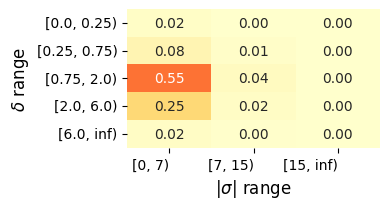

In [84]:
# Aggregate the relative share by summing over the sigma_we dimension
summary_summed = summary_df.groupby(["E", "density range"])["relative share"].sum().reset_index()

# Pivot the data with E on the x-axis and density range on the y-axis
heatmap_data_e_only = summary_summed.pivot(
    index="density range", 
    columns="E", 
    values="relative share"
)

# Pivot and reindex using original dimension labels
heatmap_data_e_only = summary_summed.pivot(
    index="density range", 
    columns="E", 
    values="relative share"
).reindex(index=density_order, columns=e_order)

# Clean the labels only for the plotting object
heatmap_data_e_only.index = [i.replace("density ", "") for i in heatmap_data_e_only.index]
heatmap_data_e_only.columns = [i.replace("E ", "") for i in heatmap_data_e_only.columns]

# Initialize and configure the heatmap plot
plt.figure(figsize=(4, 2.2))
sns.heatmap(
    heatmap_data_e_only, 
    annot=True, 
    cmap="YlOrRd", 
    vmin=0,
    vmax=1,
    cbar=False,
    fmt=".2f"
)

#plt.title("Summed Relative Share: E vs. Density")
plt.xlabel(r"$|\sigma|$ range", fontsize=12)
plt.ylabel(r"$\delta$ range", fontsize=12)

# Adjust label rotations for better readability
plt.xticks(rotation=0, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

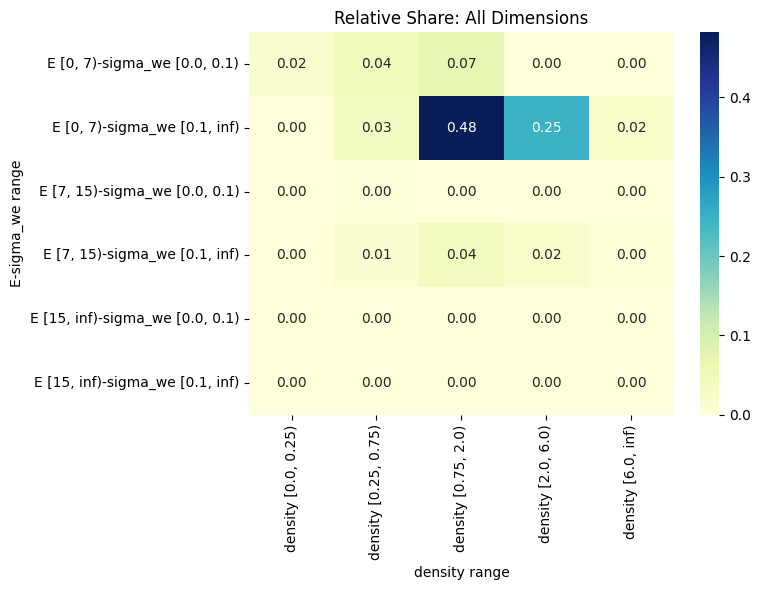

In [85]:
# Define categorical orderings for all dimensions
e_order = [
    "E [0, 7)", 
    "E [7, 15)", 
    "E [15, inf)"
]

density_order = [
    "density [0.0, 0.25)", 
    "density [0.25, 0.75)", 
    "density [0.75, 2.0)", 
    "density [2.0, 6.0)", 
    "density [6.0, inf)"
]

sigma_order = [
    "sigma_we [0.0, 0.1)", 
    "sigma_we [0.1, inf)"
]

# Pivot data to form a 2D matrix with a MultiIndex
heatmap_data_combined = summary_df.pivot(
    index=["E", "sigma_we range"], 
    columns="density range", 
    values="relative share"
)

# Construct a formal MultiIndex to enforce row ordering
row_index = pd.MultiIndex.from_product(
    [e_order, sigma_order], 
    names=["E", "sigma_we range"]
)

# Apply specific row and column ordering
heatmap_data_combined = heatmap_data_combined.reindex(
    index=row_index, 
    columns=density_order
)

# Initialize and configure the plot
plt.figure(figsize=(8, 6))
sns.heatmap(
    heatmap_data_combined, 
    annot=True, 
    cmap="YlGnBu", 
    fmt=".2f"
)

plt.title("Relative Share: All Dimensions")

# Format y-axis labels for readability
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

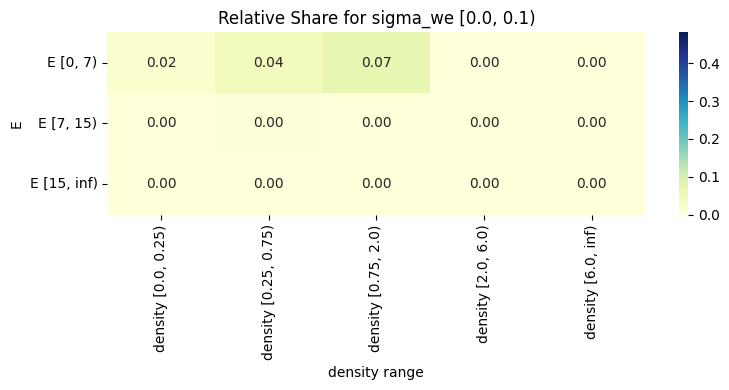

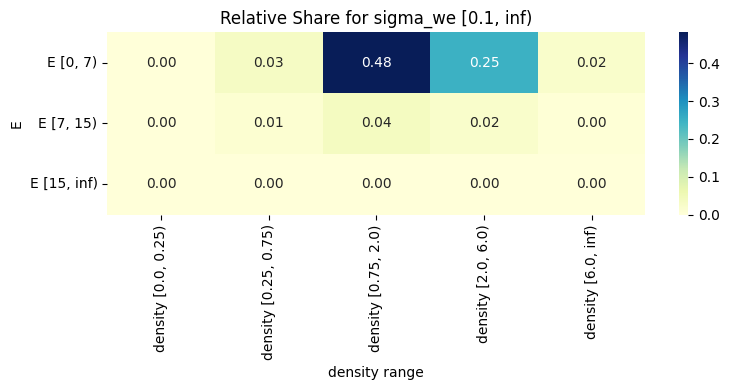

In [86]:
# Calculate global color scale limits
vmin = summary_df["relative share"].min()
vmax = summary_df["relative share"].max()

# Iterate through the ordered sigma categories
for sigma_cat in sigma_order:
    # Filter data for the current sigma range
    subset = summary_df[summary_df["sigma_we range"] == sigma_cat]
    
    # Pivot data to create the matrix
    heatmap_data_facet = subset.pivot(
        index="E", 
        columns="density range", 
        values="relative share"
    )
    
    # Reindex to enforce the specific row and column ordering
    heatmap_data_facet = heatmap_data_facet.reindex(index=e_order, columns=density_order)
    
    # Initialize and configure the plot
    plt.figure(figsize=(8, 4))
    sns.heatmap(
        heatmap_data_facet, 
        annot=True, 
        cmap="YlGnBu", 
        fmt=".2f",
        vmin=vmin,
        vmax=vmax
    )
    
    plt.title(f"Relative Share for {sigma_cat}")
    
    # Rotate y-axis labels to be horizontal
    plt.yticks(rotation=0)
    
    plt.tight_layout()
    plt.show()